In [1]:
from google.colab import files
files = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("UCI_Credit_Card.csv")

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
df.isna().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [6]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDefault rate:", df['default.payment.next.month'].mean())

Shape: (30000, 25)

Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']

Default rate: 0.2212


In [7]:
print("Null values:", df.isnull().sum().sum())
print("\nBasic stats:\n", df.describe())


Null values: 0

Basic stats:
                  ID       LIMIT_BAL           SEX     EDUCATION      MARRIAGE  \
count  30000.000000    30000.000000  30000.000000  30000.000000  30000.000000   
mean   15000.500000   167484.322667      1.603733      1.853133      1.551867   
std     8660.398374   129747.661567      0.489129      0.790349      0.521970   
min        1.000000    10000.000000      1.000000      0.000000      0.000000   
25%     7500.750000    50000.000000      1.000000      1.000000      1.000000   
50%    15000.500000   140000.000000      2.000000      2.000000      2.000000   
75%    22500.250000   240000.000000      2.000000      2.000000      2.000000   
max    30000.000000  1000000.000000      2.000000      6.000000      3.000000   

                AGE         PAY_0         PAY_2         PAY_3         PAY_4  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      35.485500     -0.016700     -0.133767     -0.166200     -0.220667   
std

Null values: 0

Basic stats:
                  ID       LIMIT_BAL           SEX     EDUCATION      MARRIAGE  \
count  30000.000000    30000.000000  30000.000000  30000.000000  30000.000000   
mean   15000.500000   167484.322667      1.603733      1.853133      1.551867   
std     8660.398374   129747.661567      0.489129      0.790349      0.521970   
min        1.000000    10000.000000      1.000000      0.000000      0.000000   
25%     7500.750000    50000.000000      1.000000      1.000000      1.000000   
50%    15000.500000   140000.000000      2.000000      2.000000      2.000000   
75%    22500.250000   240000.000000      2.000000      2.000000      2.000000   
max    30000.000000  1000000.000000      2.000000      6.000000      3.000000   

                AGE         PAY_0         PAY_2         PAY_3         PAY_4  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      35.485500     -0.016700     -0.133767     -0.166200     -0.220667   
std

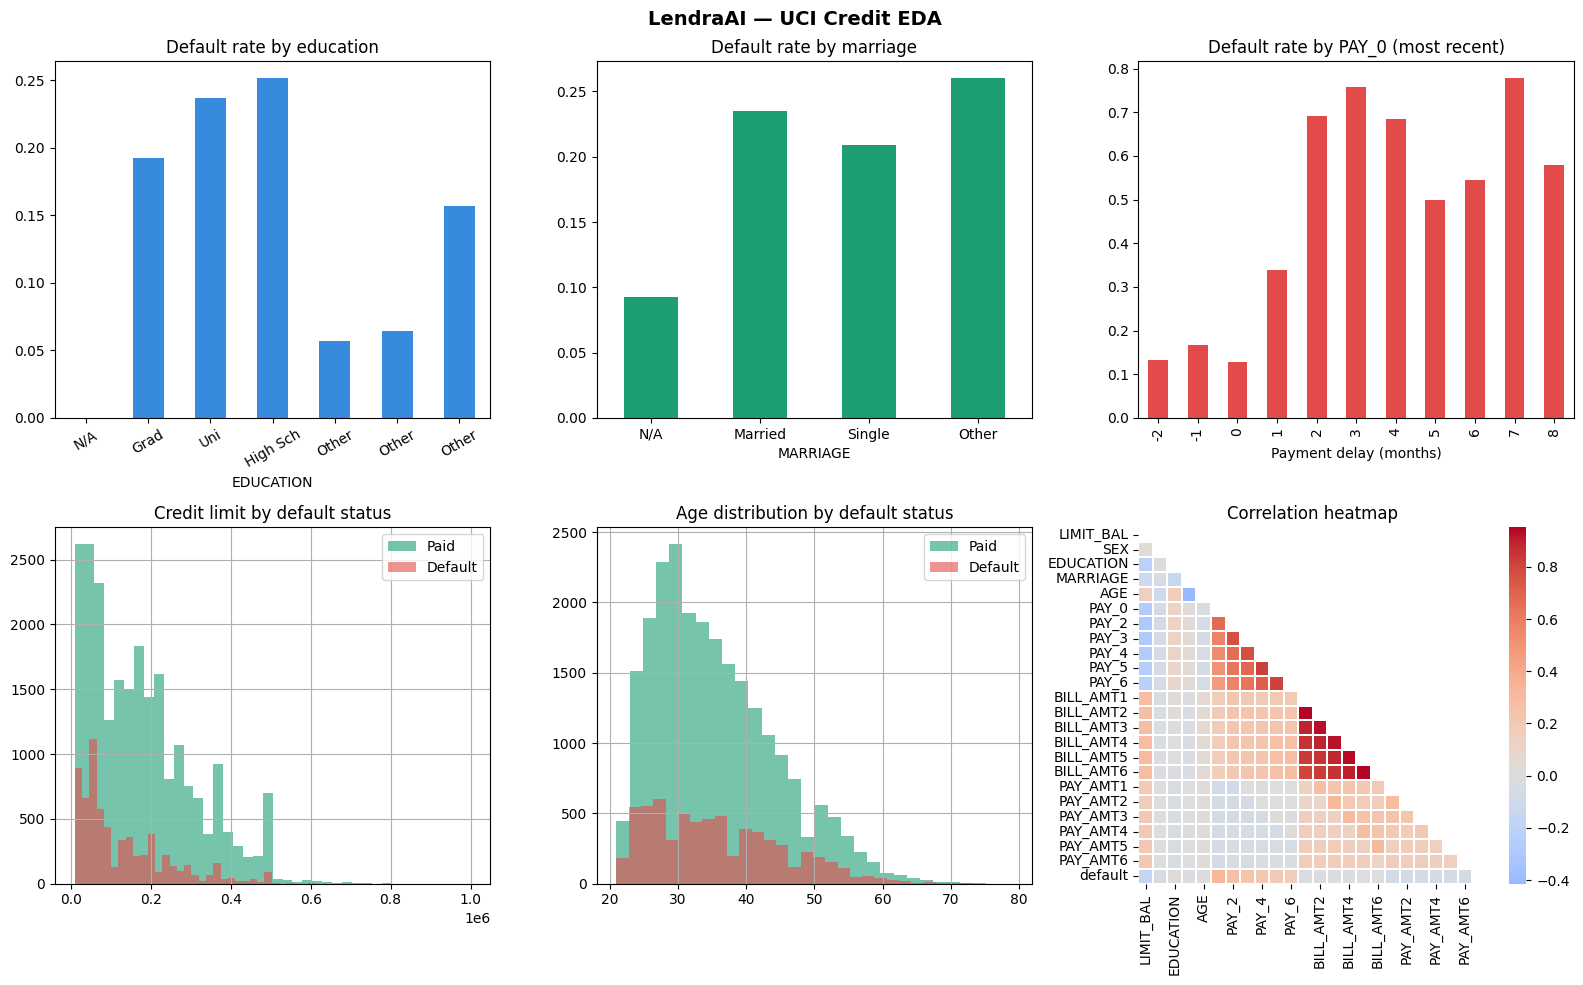


Default rate by PAY_0 (most recent payment):
PAY_0
-2    0.132
-1    0.168
 0    0.128
 1    0.339
 2    0.691
 3    0.758
 4    0.684
 5    0.500
 6    0.545
 7    0.778
 8    0.579
Name: default, dtype: float64

Correlation of PAY columns with default:
default    1.000000
PAY_0      0.324794
PAY_2      0.263551
PAY_3      0.235253
PAY_4      0.216614
PAY_5      0.204149
PAY_6      0.186866
Name: default, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Check nulls and basic stats ─
print("Null values:", df.isnull().sum().sum())
print("\nBasic stats:\n", df.describe())

# 2. Rename target column
df = df.rename(columns={'default.payment.next.month': 'default'})

# 3. Drop ID — not a feature
df = df.drop(columns=['ID'])
print(f"\nShape after dropping ID: {df.shape}")

# 4. EDA plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Default rate by education
df.groupby('EDUCATION')['default'].mean().plot(
    kind='bar', ax=axes[0,0], color='#378ADD')
axes[0,0].set_title('Default rate by education')
axes[0,0].set_xticklabels(['N/A','Grad','Uni','High Sch','Other','Other','Other'], rotation=30)

# Default rate by marriage
df.groupby('MARRIAGE')['default'].mean().plot(
    kind='bar', ax=axes[0,1], color='#1D9E75')
axes[0,1].set_title('Default rate by marriage')
axes[0,1].set_xticklabels(['N/A','Married','Single','Other'], rotation=0)

# Default rate by PAY_0 (most recent payment status)
df.groupby('PAY_0')['default'].mean().plot(
    kind='bar', ax=axes[0,2], color='#E24B4A')
axes[0,2].set_title('Default rate by PAY_0 (most recent)')
axes[0,2].set_xlabel('Payment delay (months)')

# Credit limit distribution by default
df[df['default']==0]['LIMIT_BAL'].hist(
    bins=40, alpha=0.6, ax=axes[1,0], label='Paid', color='#1D9E75')
df[df['default']==1]['LIMIT_BAL'].hist(
    bins=40, alpha=0.6, ax=axes[1,0], label='Default', color='#E24B4A')
axes[1,0].set_title('Credit limit by default status')
axes[1,0].legend()

# Age distribution by default
df[df['default']==0]['AGE'].hist(
    bins=30, alpha=0.6, ax=axes[1,1], label='Paid', color='#1D9E75')
df[df['default']==1]['AGE'].hist(
    bins=30, alpha=0.6, ax=axes[1,1], label='Default', color='#E24B4A')
axes[1,1].set_title('Age distribution by default status')
axes[1,1].legend()

# Correlation heatmap
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, ax=axes[1,2], annot=False)
axes[1,2].set_title('Correlation heatmap')

plt.suptitle('LendraAI — UCI Credit EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('uci_eda.png', dpi=150)
plt.show()

# 5. PAY columns deep dive
print("\nDefault rate by PAY_0 (most recent payment):")
print(df.groupby('PAY_0')['default'].mean().round(3))

print("\nCorrelation of PAY columns with default:")
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
print(df[pay_cols + ['default']].corr()['default'].sort_values(ascending=False))

FEATURE ENGINEERING

In [9]:
# 1. Payment delay trend — is the person getting worse or better?
df['pay_trend'] = df['PAY_0'] - df['PAY_6']
# positive = getting worse, negative = improving

In [10]:
# 2. Average payment delay across all 6 months
df['avg_pay_delay'] = df[['PAY_0','PAY_2','PAY_3',
                           'PAY_4','PAY_5','PAY_6']].mean(axis=1)

In [11]:
# 3. Max delay — worst single month
df['max_pay_delay'] = df[['PAY_0','PAY_2','PAY_3',
                           'PAY_4','PAY_5','PAY_6']].max(axis=1)

In [12]:
# 4. Number of months with any delay (PAY > 0)
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
df['months_delayed'] = (df[pay_cols] > 0).sum(axis=1)


In [13]:
# 5. Number of months paid on time or early (PAY <= 0)
df['months_on_time'] = (df[pay_cols] <= 0).sum(axis=1)


In [14]:
# 6. Average bill amount (reduce 6 columns to 1)
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
             'BILL_AMT4','BILL_AMT5','BILL_AMT6']
df['avg_bill_amt'] = df[bill_cols].mean(axis=1)

# 7. Average payment amount
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                'PAY_AMT4','PAY_AMT5','PAY_AMT6']
df['avg_pay_amt'] = df[pay_amt_cols].mean(axis=1)

# 8. Payment ratio — how much of their bill do they actually pay?
df['payment_ratio'] = df['avg_pay_amt'] / (df['avg_bill_amt'] + 1)

# 9. Credit utilisation — how much of limit are they using?
df['credit_util'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# 10. Limit to age ratio — credit limit relative to age
df['limit_per_age'] = df['LIMIT_BAL'] / df['AGE']

# 11. Bill trend — is their debt growing?
df['bill_trend'] = df['BILL_AMT1'] - df['BILL_AMT6']
# positive = debt growing, negative = debt shrinking

# 12. Pay amount trend — are they paying more or less over time?
df['pay_amt_trend'] = df['PAY_AMT1'] - df['PAY_AMT6']

# 13. High risk flag — delayed 2+ months recently
df['high_risk'] = ((df['PAY_0'] >= 2) | (df['PAY_2'] >= 2)).astype(int)

# 14. Clean up education and marriage outliers
# Education: 0, 5, 6 are undocumented — map to 4 (other)
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
# Marriage: 0 is undocumented — map to 3 (other)
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

In [15]:
# Check new features
new_features = ['pay_trend', 'avg_pay_delay', 'max_pay_delay',
                'months_delayed', 'months_on_time', 'avg_bill_amt',
                'avg_pay_amt', 'payment_ratio', 'credit_util',
                'limit_per_age', 'bill_trend', 'pay_amt_trend', 'high_risk']

print(f"New features created: {len(new_features)}")
print(f"\nNew shape: {df.shape}")

# Correlation of new features with default
print("\nNew feature correlations with default:")
print(df[new_features + ['default']].corr()['default']
      .sort_values(ascending=False).round(3))

New features created: 13

New shape: (30000, 37)

New feature correlations with default:
default           1.000
high_risk         0.403
months_delayed    0.398
max_pay_delay     0.331
avg_pay_delay     0.282
pay_trend         0.129
credit_util       0.086
payment_ratio    -0.007
pay_amt_trend    -0.012
avg_bill_amt     -0.013
bill_trend       -0.026
avg_pay_amt      -0.102
limit_per_age    -0.160
months_on_time   -0.398
Name: default, dtype: float64


In [16]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder


In [17]:
# Final feature selection
# Keep raw PAY columns + best engineered features
# Drop redundant bill/pay_amt columns (captured in engineered features)
# Drop months_on_time (mirror of months_delayed — redundant)

selected_features = [
    # Raw payment status — strongest signals
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    # Engineered payment features
    'high_risk', 'months_delayed', 'max_pay_delay',
    'avg_pay_delay', 'pay_trend',
    # Financial features
    'LIMIT_BAL', 'credit_util', 'payment_ratio',
    'avg_bill_amt', 'avg_pay_amt', 'bill_trend',
    'limit_per_age',
    # Demographics
    'AGE', 'EDUCATION', 'MARRIAGE', 'SEX',
]

In [18]:
X = df[selected_features]
y = df['default']

print(f"Feature set: {X.shape}")
print(f"Default rate: {y.mean():.1%}")


Feature set: (30000, 22)
Default rate: 22.1%


In [19]:
# fix — fill NaNs with median for numeric columns
X = X.fillna(X.median())


In [20]:
# check which columns have NaNs
print("NaNs per column:")
print(X.isnull().sum()[X.isnull().sum() > 0])

NaNs per column:
Series([], dtype: int64)



Mutual Information Scores:
       feature  mi_score
months_delayed  0.078174
         PAY_0  0.077023
 avg_pay_delay  0.072497
     high_risk  0.070644
 max_pay_delay  0.069851
         PAY_2  0.049579
         PAY_4  0.037367
         PAY_3  0.034625
         PAY_5  0.032265
         PAY_6  0.026718
     pay_trend  0.025317
   avg_pay_amt  0.023157
 limit_per_age  0.017873
 payment_ratio  0.014902
     LIMIT_BAL  0.014214
    bill_trend  0.013780
  avg_bill_amt  0.012245
   credit_util  0.012110
      MARRIAGE  0.005592
     EDUCATION  0.003792
           AGE  0.003309
           SEX  0.003106


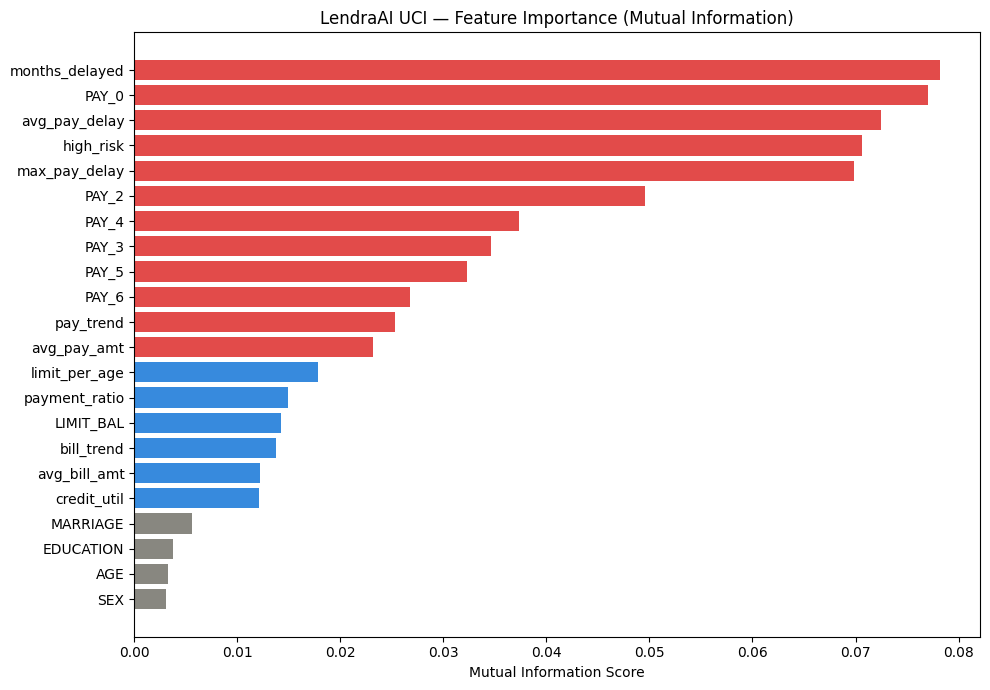


Train: (24000, 22) | Test: (6000, 22)
Train default rate: 22.1%
Test default rate:  22.1%


In [21]:
# ── Mutual information scores
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nMutual Information Scores:")
print(mi_df.to_string(index=False))

# ── Visualise
plt.figure(figsize=(10, 7))
colors = ['#E24B4A' if s > 0.02 else '#378ADD' if s > 0.01
          else '#888780' for s in mi_df['mi_score']]
plt.barh(mi_df['feature'], mi_df['mi_score'], color=colors)
plt.xlabel('Mutual Information Score')
plt.title('LendraAI UCI — Feature Importance (Mutual Information)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('uci_mi_scores.png', dpi=150)
plt.show()

# ── Train/test split ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.1%}")
print(f"Test default rate:  {y_test.mean():.1%}")

In [22]:
import xgboost as xgb
import joblib
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)

In [23]:
# ── Drop low signal demographic features
final_features = [f for f in selected_features
                  if f not in ['MARRIAGE', 'EDUCATION', 'AGE', 'SEX']]

X_train_f = X_train[final_features]
X_test_f  = X_test[final_features]

print(f"Final features: {len(final_features)}")
print(f"Features: {final_features}")

Final features: 18
Features: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'high_risk', 'months_delayed', 'max_pay_delay', 'avg_pay_delay', 'pay_trend', 'LIMIT_BAL', 'credit_util', 'payment_ratio', 'avg_bill_amt', 'avg_pay_amt', 'bill_trend', 'limit_per_age']


In [24]:
# ── Scale pos weight
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"\nscale_pos_weight: {scale:.2f}")



scale_pos_weight: 3.52


In [25]:
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=1,
)

In [26]:
model.fit(
    X_train_f, y_train,
    eval_set=[(X_train_f, y_train), (X_test_f, y_test)],
    verbose=100,
)


[0]	validation_0-auc:0.77511	validation_1-auc:0.76054
[100]	validation_0-auc:0.80422	validation_1-auc:0.77876
[200]	validation_0-auc:0.81454	validation_1-auc:0.77968
[293]	validation_0-auc:0.82361	validation_1-auc:0.77937


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.02, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [27]:
# Evaluate
y_pred = model.predict(X_test_f)
y_prob = model.predict_proba(X_test_f)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"\n{'='*40}")
print(f"  LendraAI UCI AUC-ROC: {auc:.4f}")
print(f"{'='*40}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Paid','Default'])}")



  LendraAI UCI AUC-ROC: 0.7798

              precision    recall  f1-score   support

        Paid       0.88      0.80      0.84      4673
     Default       0.47      0.63      0.54      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.72      0.69      6000
weighted avg       0.79      0.76      0.77      6000



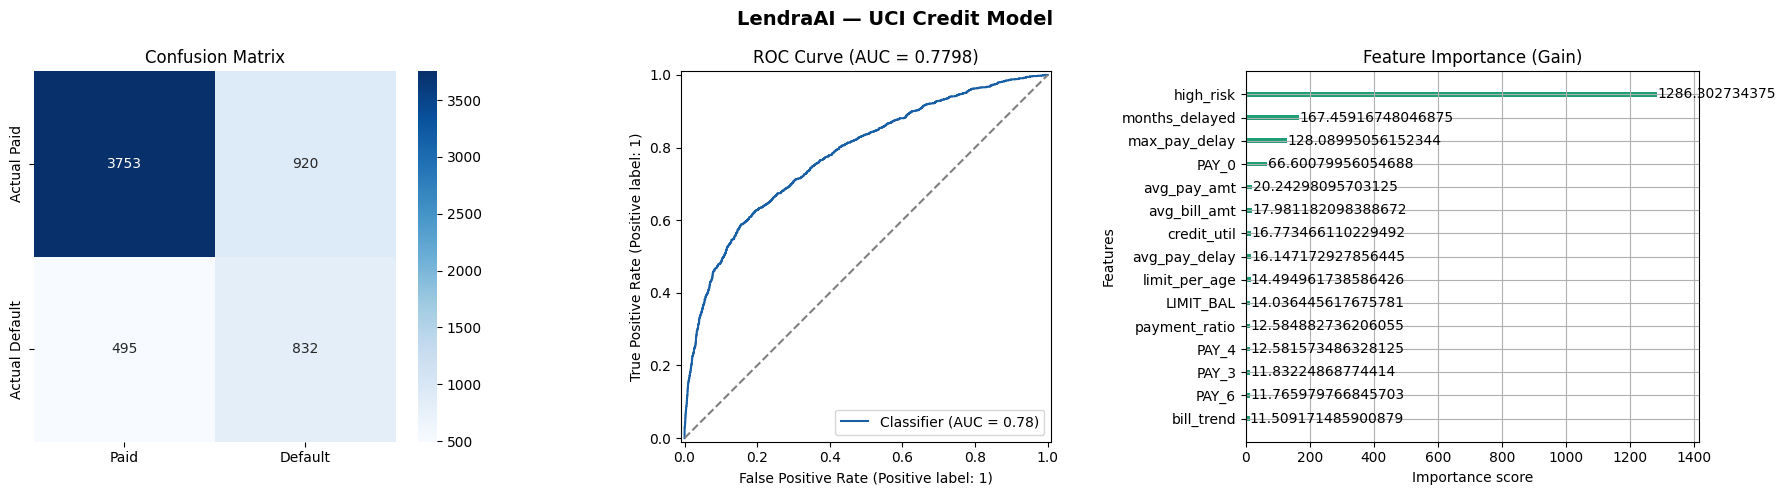

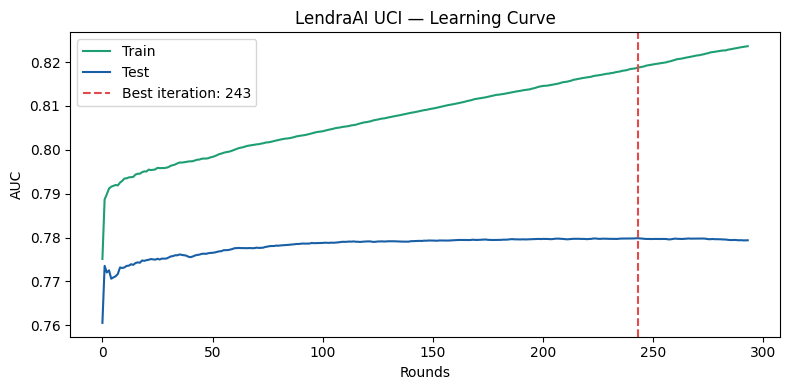


Best iteration: 243
Best test AUC:  0.7798

Model saved to ml_credit/models/lendraai_uci_model.pkl
Features saved to ml_credit/models/lendraai_uci_features.pkl


In [28]:
# ── Plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Paid','Default'],
            yticklabels=['Actual Paid','Actual Default'])
axes[0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], color='#185FA5')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title(f'ROC Curve (AUC = {auc:.4f})')

# Feature importance
xgb.plot_importance(model, ax=axes[2], max_num_features=15,
                    importance_type='gain', color='#1D9E75')
axes[2].set_title('Feature Importance (Gain)')

plt.suptitle('LendraAI — UCI Credit Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('uci_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Learning curve
results = model.evals_result()
plt.figure(figsize=(8, 4))
plt.plot(results['validation_0']['auc'], label='Train', color='#1D9E75')
plt.plot(results['validation_1']['auc'], label='Test', color='#185FA5')
plt.axvline(model.best_iteration, color='#E24B4A', linestyle='--',
            label=f'Best iteration: {model.best_iteration}')
plt.title('LendraAI UCI — Learning Curve')
plt.xlabel('Rounds')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.savefig('uci_learning_curve.png', dpi=150)
plt.show()

print(f"\nBest iteration: {model.best_iteration}")
print(f"Best test AUC:  {model.best_score:.4f}")

# Save
import os
os.makedirs('ml_credit/models', exist_ok=True)
joblib.dump(model, 'ml_credit/models/lendraai_uci_model.pkl')
joblib.dump(final_features, 'ml_credit/models/lendraai_uci_features.pkl')
print("\nModel saved to ml_credit/models/lendraai_uci_model.pkl")
print("Features saved to ml_credit/models/lendraai_uci_features.pkl")

[0]	validation_0-auc:0.78302	validation_1-auc:0.76028
[100]	validation_0-auc:0.81820	validation_1-auc:0.77763
[200]	validation_0-auc:0.83381	validation_1-auc:0.77815
[231]	validation_0-auc:0.83832	validation_1-auc:0.77803

  v1 AUC: 0.7798
  v2 AUC: 0.7784

              precision    recall  f1-score   support

        Paid       0.88      0.81      0.84      4673
     Default       0.48      0.61      0.54      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



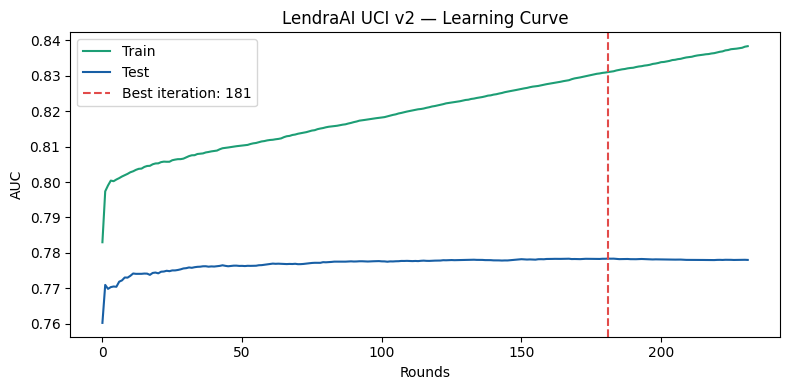


v1 still better (0.7798) — keeping v1


In [29]:
# ── Round 2 — push past 0.80
model_v2 = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=6,        # increase from 5
    learning_rate=0.02,
    subsample=0.85,     # increase slightly
    colsample_bytree=0.85,
    min_child_weight=3, # reduce from 5 — allow finer splits
    gamma=0.05,         # reduce from 0.1
    reg_alpha=0.05,
    reg_lambda=1.0,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,
    verbosity=1,
)

model_v2.fit(
    X_train_f, y_train,
    eval_set=[(X_train_f, y_train), (X_test_f, y_test)],
    verbose=100,
)

y_pred_v2 = model_v2.predict(X_test_f)
y_prob_v2 = model_v2.predict_proba(X_test_f)[:, 1]
auc_v2 = roc_auc_score(y_test, y_prob_v2)

print(f"\n{'='*40}")
print(f"  v1 AUC: 0.7798")
print(f"  v2 AUC: {auc_v2:.4f}")
print(f"{'='*40}")
print(f"\n{classification_report(y_test, y_pred_v2, target_names=['Paid','Default'])}")

# learning curve
results_v2 = model_v2.evals_result()
plt.figure(figsize=(8, 4))
plt.plot(results_v2['validation_0']['auc'], label='Train', color='#1D9E75')
plt.plot(results_v2['validation_1']['auc'], label='Test', color='#185FA5')
plt.axvline(model_v2.best_iteration, color='#E24B4A', linestyle='--',
            label=f'Best iteration: {model_v2.best_iteration}')
plt.title('LendraAI UCI v2 — Learning Curve')
plt.xlabel('Rounds')
plt.ylabel('AUC')
plt.legend()
plt.tight_layout()
plt.savefig('uci_learning_curve_v2.png', dpi=150)
plt.show()

# save if better
if auc_v2 > 0.7798:
    joblib.dump(model_v2, 'ml_credit/models/lendraai_uci_model.pkl')
    print(f"\nv2 is better ({auc_v2:.4f}) — model updated and saved!")
else:
    print(f"\nv1 still better (0.7798) — keeping v1")

In [30]:
# BUILDING THE SHAP EXPLAINER
import shap

SHAP values shape: (6000, 18)


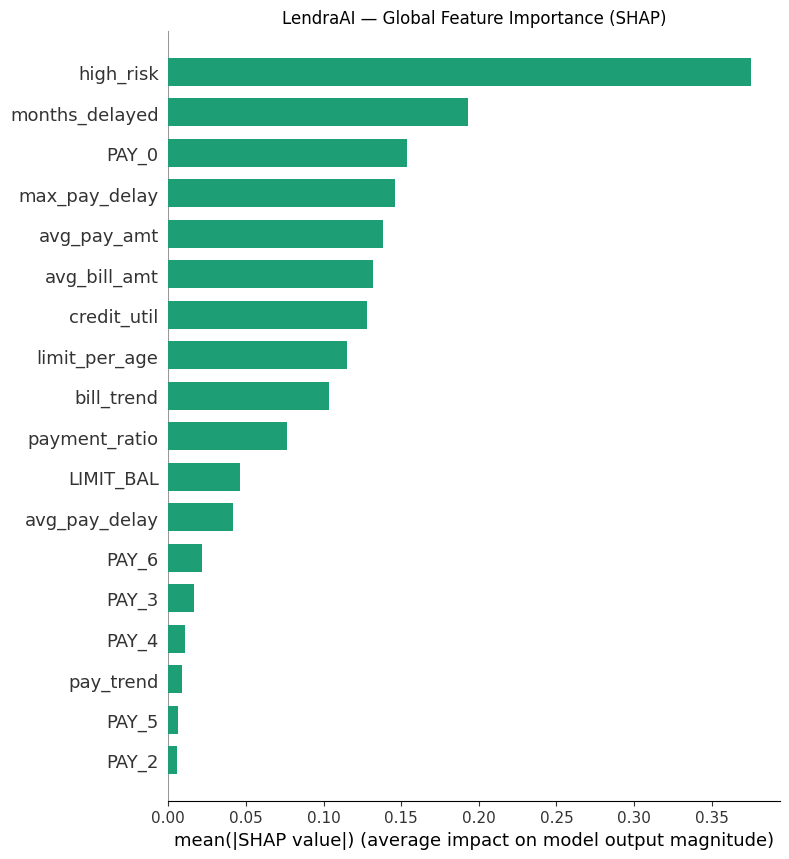

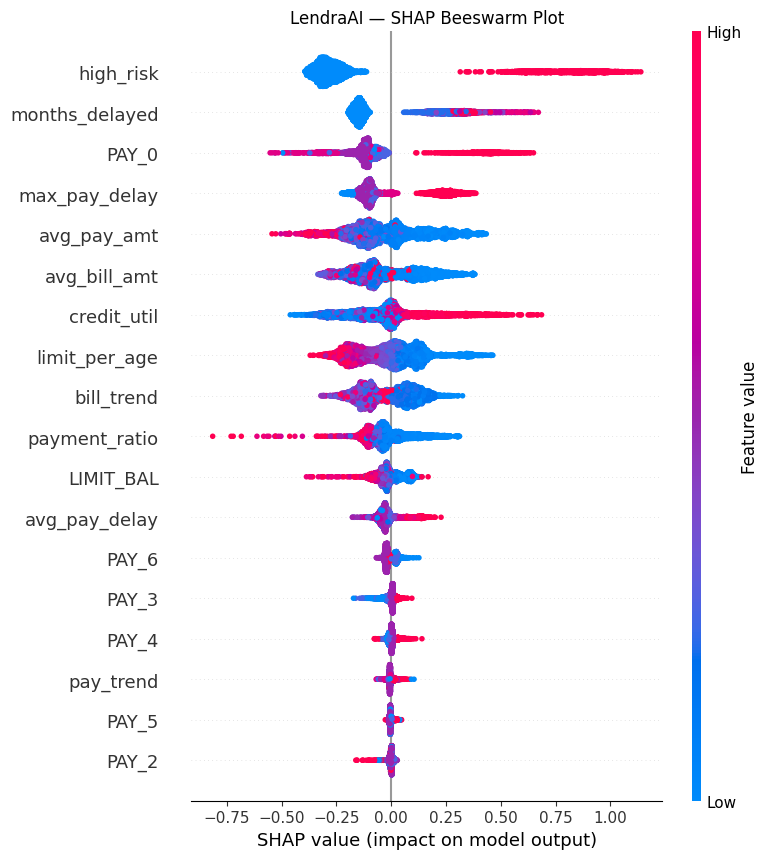


Sample customer (high risk):
                        29382
PAY_0                1.000000
PAY_2                2.000000
PAY_3                0.000000
PAY_4                0.000000
PAY_5                0.000000
PAY_6                0.000000
high_risk            1.000000
months_delayed       2.000000
max_pay_delay        2.000000
avg_pay_delay        0.500000
pay_trend            1.000000
LIMIT_BAL       200000.000000
credit_util          0.997080
payment_ratio        0.334618
avg_bill_amt    196588.666667
avg_pay_amt      65782.500000
bill_trend       -4705.000000
limit_per_age     6896.551724

Actual default: 0
Predicted probability: 51.4%


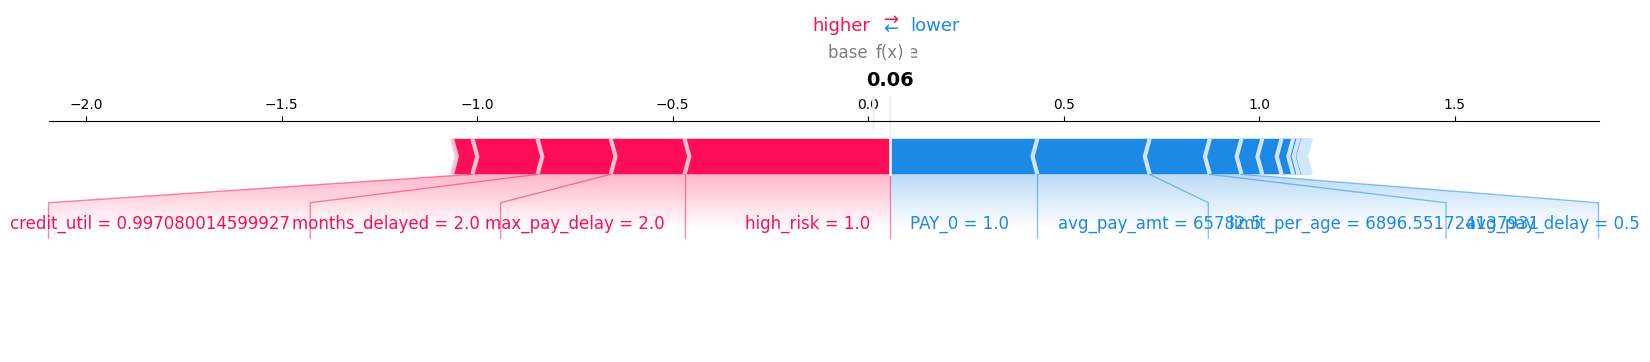


  Current credit score:  567
  Simulated score:       642
  Improvement:           +75 points

SHAP explainer saved!


In [31]:

# ── Load best model (v1)
best_model = joblib.load('ml_credit/models/lendraai_uci_model.pkl')

# ── SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_f)

print("SHAP values shape:", shap_values.shape)

# ── Plot 1 — Summary plot (global feature importance)
plt.figure()
shap.summary_plot(shap_values, X_test_f, plot_type='bar',
                  show=False, color='#1D9E75')
plt.title('LendraAI — Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('uci_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2 — Beeswarm (how each feature affects the score)
plt.figure()
shap.summary_plot(shap_values, X_test_f, show=False)
plt.title('LendraAI — SHAP Beeswarm Plot')
plt.tight_layout()
plt.savefig('uci_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3 — Single prediction explanation
# explain one high-risk customer
sample_idx = X_test_f[X_test_f['high_risk'] == 1].index[0]
sample = X_test_f.loc[[sample_idx]]
sample_pos = X_test_f.index.get_loc(sample_idx)

print(f"\nSample customer (high risk):")
print(sample.T)
print(f"\nActual default: {y_test.iloc[sample_pos]}")
print(f"Predicted probability: {best_model.predict_proba(sample)[0][1]:.1%}")

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_pos],
    sample,
    matplotlib=True,
    show=False
)
plt.savefig('uci_shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Score Improvement Simulator function
def simulate_score(customer_data, changes):
    """
    customer_data: dict of feature values
    changes: dict of feature changes to simulate
    e.g. changes = {'months_delayed': 0, 'high_risk': 0}
    """
    import pandas as pd
    base = pd.DataFrame([customer_data])
    modified = base.copy()
    for feature, new_value in changes.items():
        modified[feature] = new_value

    base_prob = best_model.predict_proba(base)[0][1]
    new_prob  = best_model.predict_proba(modified)[0][1]
    base_score  = round(300 + (1 - base_prob) * 550)
    new_score   = round(300 + (1 - new_prob) * 550)

    print(f"\n{'='*45}")
    print(f"  Current credit score:  {base_score}")
    print(f"  Simulated score:       {new_score}")
    print(f"  Improvement:           +{new_score - base_score} points")
    print(f"{'='*45}")
    return base_score, new_score

# test the simulator with a sample customer
customer = X_test_f.iloc[sample_pos].to_dict()
simulate_score(
    customer,
    changes={
        'months_delayed': 0,
        'high_risk': 0,
        'max_pay_delay': 0,
        'avg_pay_delay': -1
    }
)

# ── Save explainer
joblib.dump(explainer, 'ml_credit/models/lendraai_shap_explainer.pkl')
print("\nSHAP explainer saved!")

In [32]:
from google.colab import files

In [33]:
files.download("ml_credit/models/lendraai_shap_explainer.pkl")
files.download("ml_credit/models/lendraai_uci_model.pkl")
files.download("ml_credit/models/lendraai_uci_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>